# Bloomberg Dataset Analysis

This notebook is used to clean the Bloomberg Financial News dataset. You can run `bloomberg_data_download.py` to download the raw dataset to use this notebook.

## Setup

In [4]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Get the current directory
current_dir = Path.cwd()

# Go up one level to FYP
project_root = current_dir.parent.parent.parent
sys.path.append(str(project_root))
data_path = project_root / "data" / "raw" / "bloomberg" / "bloomberg_financial_data.parquet"

# Read the dataset
df = pd.read_parquet(data_path)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (446762, 5)


,Headline,Journalists,Date,Link,Article
0,"Ivory Coast Keeps Cocoa Export Tax Below 22%, ...",[Baudelaire Mieu],2011-10-06 15:14:20,http://www.bloomberg.com/news/2011-10-06/ivory...,"Export taxes on cocoa beans from Ivory Coast ,..."
1,USDA Boxed Beef Cutout Closing Prices for Octo...,[Michael Carone],2011-10-06 20:22:42,http://www.bloomberg.com/news/2011-10-06/usda-...,October 6 (Bloomberg) -- This table details bo...
2,U.S. September Small Business Jobs Summary,[Alex Tanzi],2011-10-06 19:00:00,http://www.bloomberg.com/news/2011-10-06/u-s-s...,U.S. small business plans to hire declined in ...
3,Greece’s GSEE Says Won’t Meet For Talks With T...,[Natalie Weeks],2011-10-06 14:45:34,http://www.bloomberg.com/news/2011-10-06/greec...,"Greece ’s biggest private sector union group, ..."
4,Clean-Tech Companies Should Get 10-Year Tax Br...,[Ari Levy],2011-10-06 18:34:41,http://www.bloomberg.com/news/2011-10-06/clean...,"Reed Hundt, head of the Coalition for Green Ca..."


# Token counting
Since we will use NLP model to extract feature, it is important to understant the token count before we input

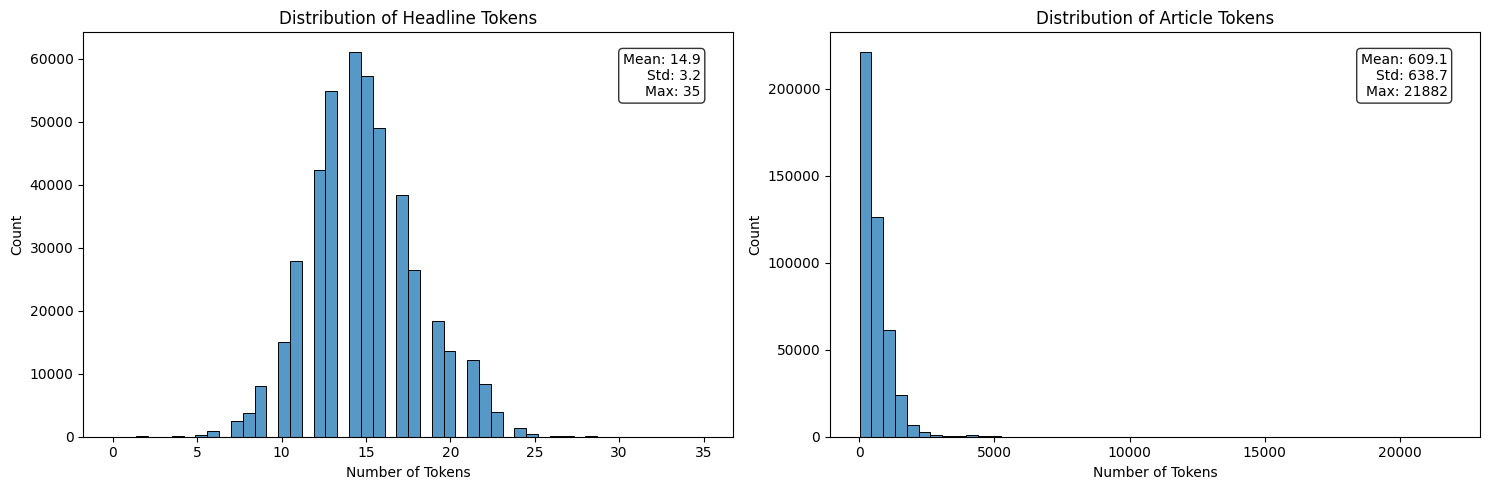


Headline Token Statistics:
count    446762.000000
mean         14.861374
std           3.210445
min           0.000000
25%          13.000000
50%          15.000000
75%          17.000000
max          35.000000
Name: Headline, dtype: float64


KeyboardInterrupt: 

In [5]:
from src.utils.plot_df import plot_token_distribution, print_token_statistics

# Plot distributions
plot_token_distribution(df, ['Headline', 'Article'])

# Print statistics
print_token_statistics(df, ['Headline', 'Article'])

# Distribution by day

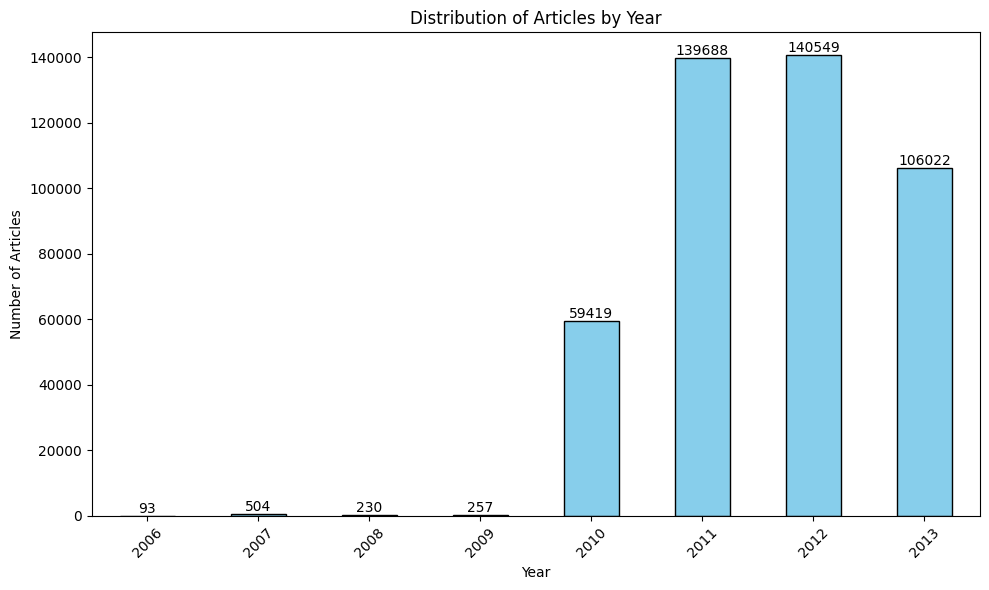

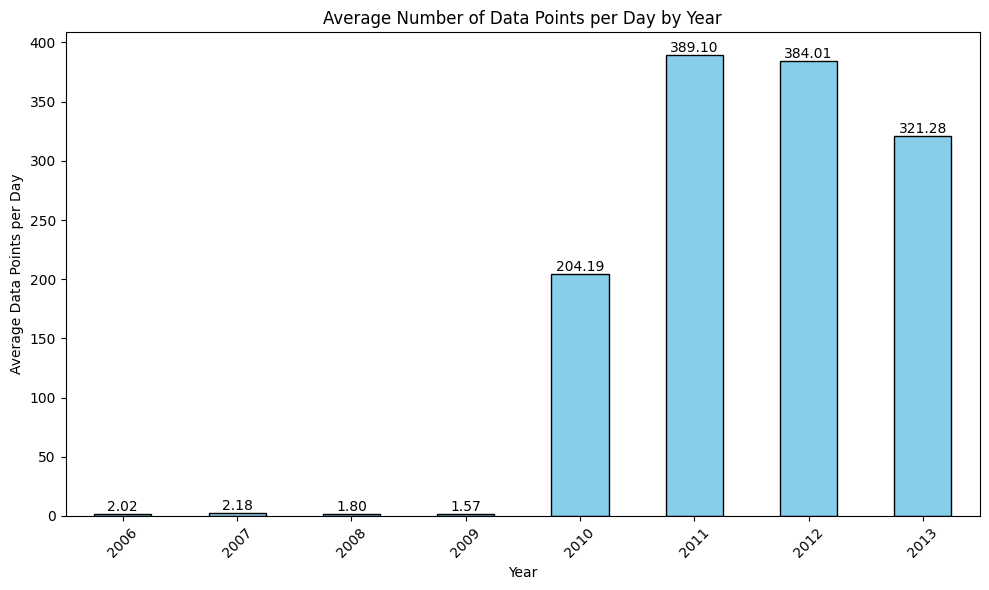

In [6]:
from src.utils.plot_df import plot_distribution_by_year, plot_description_length_distribution, plot_avg_per_day_by_year

plot_distribution_by_year(df, 'Date')
plot_avg_per_day_by_year(df, 'Date')

# Data Cleaning
We found that using the `Headline` as the input to the model is practical. This session remove unrelated column to reduce the size of the df in term of the resource and performance.

In [13]:
# Sort by date and remove duplicate headlines
print(f"Original dataset shape: {df.shape}")
old_count = df.shape[0]

# Extract year from Date column and create a new column
df['year'] = pd.to_datetime(df['Date']).dt.year

# Sort by date in ascending order
cleaned_df = df.sort_values('Date')

# Filter data to keep only rows from 2010 onwards
cleaned_df = cleaned_df[cleaned_df['year'] < 2010]

# Remove duplicates based on headline, keeping the first occurrence
cleaned_df = cleaned_df.drop_duplicates(subset=['Headline'], keep='first')

# Select and keep specific columns to CSV
columns_to_keep = ['Headline', 'Date']
cleaned_df = cleaned_df[columns_to_keep]

# Print results
print(f"Dataset shape after removing duplicates: {cleaned_df.shape}")
print(f"Number of duplicates removed: {old_count - cleaned_df.shape[0]}")

# Display the first few rows to verify the sorting
cleaned_df.head()

Original dataset shape: (446762, 6)
Dataset shape after removing duplicates: (1084, 2)
Number of duplicates removed: 445678


,Headline,Date
45732,"Inco's Net Soars on Higher Metal Prices, Break...",2006-10-20 20:16:16
15839,"Jim Cramer: Diageo, Anheuser-Busch, Monster Wo...",2006-10-21 00:08:44
259883,EU Energy Chief Backs German Plan for Price Co...,2006-10-23 11:51:36
259882,Ex-Plant Worker Shuster Pleads Guilty in Tradi...,2006-10-23 20:00:29
255216,"Jim Cramer: Bare Escentuals, Allergan, Medicis...",2006-10-24 01:32:04


# Lowercase the column name

In [14]:
# Convert column names to lowercase
cleaned_df.columns = cleaned_df.columns.str.lower()

# List date range

In [16]:
from src.utils.data_format import convert_datetime_column

cleaned_df = convert_datetime_column(cleaned_df, 'date')
cleaned_df.head()

# Get min and max dates
min_date = cleaned_df['date'].min()
max_date = cleaned_df['date'].max()

print(f"Date range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
print(f"Total number of days: {(max_date - min_date).days}")


Date range: 2006-10-20 to 2009-12-31
Total number of days: 1167


# Insert Sentiment

In [ ]:
from src.utils.sentiment import add_sentiment_scores

# Add sentiment scores to the filtered DataFrame
cleaned_df = add_sentiment_scores(cleaned_df, 'headline')

# Save to csv


In [19]:
SAVE_PATH = project_root / "data" / "processed" / "bloomberg" 
cleaned_df.to_csv(str(SAVE_PATH) + "/sentiment_inserted_06.csv", index=False)